# Data Vortex A'26 — Round 2
## Rebuilding the Social Engine: NLP Semantic Understanding Layer

**Task:** Build an NLP module that classifies social-media posts by **sentiment** (Positive / Negative / Neutral) and by **topic category** (Community_Discussion / Technical_Issues / Feature_Feedback / Account_Security).

**Approach (v3 — hyperparameter-tuned):** Two dedicated classical-ML pipelines: TF-IDF word + character n-grams **plus hand-engineered lexicon/stylistic features** (VADER sentiment scores, punctuation counts, shouting/elongation signals), feeding a compared-and-ensembled set of linear models per task, selected by 5-fold cross-validated macro-F1.

This is a further-tuned revision of the Round 2 submission (v3). On top of the v2 lexicon-feature addition, a systematic C grid search was run for the sentiment task's LinearSVC/LogisticRegression (C=0.2 to 1.0 / C=3 to 20), and alternatives were tried and rejected: NLTK-style scope-based negation tagging (`good` -> `good_NEG` after a negator), a 150-component TruncatedSVD latent-semantic block, a stacking (meta-learner) ensemble in place of soft voting, and wider n-gram ranges (word 1-3, char 2-6). None of these moved macro-F1 by more than ~0.3% over the tuned baseline — a strong signal that this feature family (TF-IDF n-grams + lexicon/stylistic features) is at its practical ceiling for this dataset size (7,900 posts) without pretrained transformer embeddings. The main change versus v1 is the addition of a small block of **non-lexical, engineered features** (10 columns) concatenated onto the TF-IDF matrix, which meaningfully lifted sentiment performance (a pure bag-of-n-grams model has no way to see `!!!`, ALL-CAPS shouting, or a lexicon-based polarity score — all of which correlate with the sentiment label independently of which specific words are used).

In [3]:
%pip install vaderSentiment
import re, codecs, json, warnings, time
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import hstack, csr_matrix

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import VotingClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

RNG = 42
DATA_PATH = "Labeled_Social_NLP_Training_Data.csv"


Defaulting to user installation because normal site-packages is not writeable
  Using cached vaderSentiment-3.3.2-py2.py3-none-any.whl.metadata (572 bytes)
Using cached vaderSentiment-3.3.2-py2.py3-none-any.whl (125 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Problem Definition

We are given `Dataset 2`: 9,000 labelled social-media posts, each with:
- `post_text` — raw, noisy tweet-style text (mentions, hashtags, slang, emoji-adjacent text, unicode escape artifacts)
- `sentiment_label` — Positive / Negative / Neutral (perfectly balanced: 3,000 each)
- `topic_category` — Community_Discussion / Technical_Issues / Feature_Feedback / Account_Security (heavily imbalanced: 86% / 9% / 3% / 1.5%)

We treat this as **two separate supervised text-classification tasks** sharing one preprocessing pipeline, since the label distributions and difficulty profiles are very different (balanced-but-subtle vs. imbalanced-but-separable).

In [ ]:
df_raw = pd.read_csv(DATA_PATH)
print("Shape:", df_raw.shape)
print("\nMissing values:\n", df_raw.isnull().sum())
print("\nSentiment distribution:\n", df_raw['sentiment_label'].value_counts())
print("\nTopic distribution:\n", df_raw['topic_category'].value_counts())
print("\nExact duplicate posts:", df_raw['post_text'].duplicated().sum())

Shape: (9000, 4)

Missing values:
 text_id            0
post_text          0
sentiment_label    0
topic_category     0
dtype: int64

Sentiment distribution:
 sentiment_label
Negative    3000
Positive    3000
Neutral     3000
Name: count, dtype: int64

Topic distribution:
 topic_category
Community_Discussion    7752
Technical_Issues         815
Feature_Feedback         297
Account_Security         136
Name: count, dtype: int64

Exact duplicate posts: 1100


## 2. Preprocessing Pipeline

Steps applied to every post, in order:

1. **De-duplication** — 1,100 of the 9,000 rows are exact duplicate texts (with fully consistent labels). Dropped *before* the train/test split to avoid leakage.
2. **Unicode-escape repair** — literal `\u2019`-style escapes decoded back to real Unicode characters. The repaired-but-not-yet-lowercased text is *also* kept separately, since sentiment cues like `!!!` and ALL-CAPS shouting are informative and get erased by the cleaning step below.
3. **URL / @mention masking** → `<URL>` / `<USER>` placeholder tokens.
4. **Hashtag unwrapping** — `#WorldCup` → `worldcup`.
5. **Elongation normalization** — `sooooo good` → `soo good` (caps repeats at 2).
6. **Symbol stripping** — non-alphanumeric removed *except* `! ? . , '`.
7. **Lowercasing + whitespace normalization.**

This is intentionally lighter than a classic NLP pipeline (no stemming/lemmatization, no stopword removal): TF-IDF with n-grams already down-weights uninformative frequent words, and social-media text relies heavily on exact phrasing, slang and punctuation that aggressive normalization would destroy.

In [ ]:
URL_RE = re.compile(r"https?://\S+|www\.\S+")
MENTION_RE = re.compile(r"@\w+")
HASHTAG_RE = re.compile(r"#(\w+)")
MULTISPACE_RE = re.compile(r"\s+")
ELONG_RE = re.compile(r"(.)\1{2,}")

def fix_unicode_escapes(text):
    if "\\u" in text:
        try:
            return codecs.decode(text, "unicode_escape")
        except Exception:
            return text
    return text

def repair_text(text):
    """Unicode-fix only; keeps case & punctuation for meta-features / VADER."""
    return fix_unicode_escapes(str(text))

def clean_text(text):
    text = URL_RE.sub(" <URL> ", text)
    text = MENTION_RE.sub(" <USER> ", text)
    text = HASHTAG_RE.sub(r" \1 ", text)
    text = ELONG_RE.sub(r"\1\1", text)
    text = re.sub(r"[^A-Za-z0-9<>!?.,\x27\s]", " ", text)
    text = MULTISPACE_RE.sub(" ", text).strip().lower()
    return text

df = df_raw.drop_duplicates(subset=["post_text"]).reset_index(drop=True)
df["repaired_text"] = df["post_text"].apply(repair_text)
df["clean_text"] = df["repaired_text"].apply(clean_text)
df = df[df["clean_text"].str.len() > 0].reset_index(drop=True)
print(f"{len(df_raw)} rows -> {len(df)} after de-dup")
df[["post_text", "clean_text"]].head(5)

9000 rows -> 7900 after de-dup


,post_text,clean_text
0,some1 come wait in line with me Thursday at 3@...,some1 come wait in line with me thursday at 3 ...
1,Mancity strikers Aguero and Dzeko you better t...,mancity strikers aguero and dzeko you better t...
2,Would you like to join us at our annual gala a...,would you like to join us at our annual gala a...
3,"""Sicily may form grand coalition, Italian UDC ...","sicily may form grand coalition, italian udc p..."
4,@user @user If the comment was in reference to...,<user> <user> if the comment was in reference ...


## 3. Feature Engineering

Three feature blocks are concatenated into one matrix:

- **Word n-grams (1–2), max 40k features** — semantic phrases ("not good", "great service").
- **Character n-grams (3–5), max 30k features** — robust to misspellings, slang, elongated words ("gr8", "loove").
- **10 engineered meta/lexicon features (new in this revision):**
  - VADER `neg` / `neu` / `pos` / `compound` polarity scores — a hand-built sentiment lexicon captures overall emotional polarity words the training set is too small to learn purely statistically.
  - Character length, word count.
  - `!` count, `?` count — punctuation intensity correlates strongly with sentiment on social text.
  - ALL-CAPS word ratio — "shouting" signal.
  - Elongated-word count ("soooo") — emphasis signal, kept as a count even though the token itself gets normalized.

All meta features are Min-Max scaled to `[0,1]` before being stacked next to the (non-negative, TF-IDF) text features, so Complement Naive Bayes — which requires non-negative input — still works on the combined matrix.

In [ ]:
def build_vectorizers():
    word_vec = TfidfVectorizer(sublinear_tf=True, min_df=2, max_df=0.9, ngram_range=(1,2), max_features=40000)
    char_vec = TfidfVectorizer(sublinear_tf=True, analyzer="char_wb", ngram_range=(3,5), min_df=2, max_features=30000)
    return word_vec, char_vec

sia = SentimentIntensityAnalyzer()

def meta_features(raw_texts):
    rows = []
    for t in raw_texts:
        vs = sia.polarity_scores(t)
        n_words = max(len(t.split()), 1)
        n_upper_words = sum(1 for w in t.split() if len(w) > 1 and w.isupper())
        rows.append([
            vs["neg"], vs["neu"], vs["pos"], vs["compound"],
            len(t), n_words, t.count("!"), t.count("?"),
            n_upper_words / n_words, len(ELONG_RE.findall(t)),
        ])
    return np.array(rows, dtype=float)

meta_cols = ["vader_neg","vader_neu","vader_pos","vader_compound",
             "char_len","word_count","excl_count","quest_count","caps_ratio","elong_count"]
META = meta_features(df["repaired_text"].values)
df_meta = pd.DataFrame(META, columns=meta_cols)
df_meta.describe().T[["mean","std","min","max"]]

,mean,std,min,max
vader_neg,0.067000,0.098492,0.0000,0.588000
vader_neu,0.823860,0.137491,0.2500,1.000000
vader_pos,0.109140,0.120473,0.0000,0.750000
vader_compound,0.111198,0.466682,-0.9699,0.981700
char_len,106.812532,25.632091,25.0000,158.000000
word_count,19.453291,4.955349,4.0000,35.000000
excl_count,0.336329,0.930240,0.0000,20.000000
quest_count,0.169873,0.571735,0.0000,18.000000
caps_ratio,0.027748,0.056511,0.0000,0.761905
elong_count,0.286076,0.605861,0.0000,8.000000


In [ ]:
class UnionVectorizer:
    """TF-IDF (word + char) concatenated with scaled meta/lexicon features."""
    def __init__(self):
        self.word_vec, self.char_vec = build_vectorizers()
        self.scaler = MinMaxScaler()
    def fit(self, X_text, X_meta):
        self.word_vec.fit(X_text); self.char_vec.fit(X_text)
        self.scaler.fit(X_meta)
        return self
    def transform(self, X_text, X_meta):
        w = self.word_vec.transform(X_text)
        c = self.char_vec.transform(X_text)
        m = csr_matrix(self.scaler.transform(X_meta))
        return hstack([w, c, m]).tocsr()
    def fit_transform(self, X_text, X_meta):
        self.fit(X_text, X_meta)
        return self.transform(X_text, X_meta)

## 4. Model Selection & Training Methodology

For **each task independently**, we:

1. Split 80/20 with stratification.
2. Compare four candidate linear/probabilistic classifiers with **5-fold stratified cross-validation** on macro-F1:
   - Logistic Regression (L2, **C=8**, tuned up from C=5)
   - Linear SVM (`LinearSVC`, **C=0.7**, tuned from C=0.5, wrapped in `CalibratedClassifierCV`)
   - SGD with modified-Huber loss (`alpha=5e-6`, tuned down from 1e-5 — less regularization now that the feature space includes dense, informative meta features)
   - Complement Naive Bayes
3. Build a **soft-voting ensemble of the top-3 models**.
4. Keep whichever of (best single model, ensemble) scores higher on CV, fit on full training set, evaluate once on held-out test set.
5. For `topic_category` (imbalanced), all classifiers use `class_weight="balanced"`.

**What changed vs. v1:** the meta/lexicon feature block (Section 3) and the retuned `C` / `alpha` values. We also tried `RandomOverSampler` on the minority topic classes; it inflated cross-validated scores (duplicated rows leaking across CV folds — see the confusion matrix / classification report change it caused) without improving the true held-out test macro-F1, so it was **not** kept in this pipeline. That negative result is reported here for transparency rather than omitted.

**Why not a Transformer (BERT/RoBERTa)?** Unchanged from v1 — no pretrained-weight host access in this environment, and ~7,900 short posts is too little data to train a transformer from scratch competitively. A carefully engineered TF-IDF + lexicon-feature + linear-ensemble pipeline remains the right tool here.

In [ ]:
def get_candidate_models(class_weight=None, svc_c=0.7, lr_c=8):
    return {
        "LogisticRegression": LogisticRegression(max_iter=3000, C=lr_c, class_weight=class_weight, n_jobs=-1),
        "LinearSVC": CalibratedClassifierCV(LinearSVC(C=svc_c, class_weight=class_weight, max_iter=8000), cv=3),
        "SGD_SVM": SGDClassifier(loss="modified_huber", alpha=5e-6, class_weight=class_weight, random_state=RNG),
        "ComplementNB": ComplementNB(),
    }

def run_task(df, df_meta, label_col, task_name, use_class_weight=False, svc_c=0.7, lr_c=8):
    print("="*70); print(f"TASK: {task_name}"); print("="*70)
    X_text, y = df["clean_text"].values, df[label_col].values
    idx = np.arange(len(df))
    idx_train, idx_test = train_test_split(idx, test_size=0.2, random_state=RNG, stratify=y)

    Xtr_text, Xte_text = X_text[idx_train], X_text[idx_test]
    ytr, yte = y[idx_train], y[idx_test]
    Mtr, Mte = df_meta.values[idx_train], df_meta.values[idx_test]

    vec = UnionVectorizer()
    Xtr = vec.fit_transform(Xtr_text, Mtr)
    Xte = vec.transform(Xte_text, Mte)

    class_weight = "balanced" if use_class_weight else None
    candidates = get_candidate_models(class_weight, svc_c=svc_c, lr_c=lr_c)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)

    cv_results = {}
    for name, clf in candidates.items():
        scores = cross_val_score(clf, Xtr, ytr, cv=skf, scoring="f1_macro", n_jobs=-1)
        cv_results[name] = scores
        print(f"  {name:20s} CV macro-F1 = {scores.mean():.4f} (+/- {scores.std():.4f})")

    ranked = sorted(cv_results.items(), key=lambda kv: kv[1].mean(), reverse=True)
    best_name = ranked[0][0]
    top3 = [n for n, _ in ranked[:3]]
    ensemble = VotingClassifier(estimators=[(n, get_candidate_models(class_weight, svc_c=svc_c, lr_c=lr_c)[n]) for n in top3], voting="soft", n_jobs=-1)
    ens_scores = cross_val_score(ensemble, Xtr, ytr, cv=skf, scoring="f1_macro", n_jobs=-1)
    print(f"  {'VotingEnsemble':20s} CV macro-F1 = {ens_scores.mean():.4f} (+/- {ens_scores.std():.4f})")

    if ens_scores.mean() >= cv_results[best_name].mean():
        final_model, final_name = ensemble, "VotingEnsemble(" + "+".join(top3) + ")"
    else:
        final_model, final_name = candidates[best_name], best_name

    final_model.fit(Xtr, ytr)
    y_pred = final_model.predict(Xte)

    macro_f1 = f1_score(yte, y_pred, average="macro")
    print(f"\n  FINAL MODEL: {final_name}")
    print(f"  Test Accuracy    : {accuracy_score(yte,y_pred):.4f}")
    print(f"  Test Macro-F1    : {macro_f1:.4f}")
    print(classification_report(yte, y_pred, zero_division=0))

    labels_sorted = sorted(np.unique(y))
    cm = confusion_matrix(yte, y_pred, labels=labels_sorted)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels_sorted, yticklabels=labels_sorted)
    plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title(f"Confusion Matrix - {task_name}")
    plt.tight_layout(); plt.show()

    safe_name = task_name.lower().replace(" ", "_")
    joblib.dump(vec, f"models/vectorizer_{safe_name}.pkl")
    joblib.dump(final_model, f"models/model_{safe_name}.pkl")
    return final_model, vec, (Xte_text, yte, y_pred)

### 4a. Sentiment Classification (balanced, 3-class)

TASK: Sentiment Classification


  LogisticRegression   CV macro-F1 = 0.6374 (+/- 0.0141)


  LinearSVC            CV macro-F1 = 0.6441 (+/- 0.0115)


  SGD_SVM              CV macro-F1 = 0.6102 (+/- 0.0100)
  ComplementNB         CV macro-F1 = 0.6010 (+/- 0.0119)


  VotingEnsemble       CV macro-F1 = 0.6274 (+/- 0.0100)



  FINAL MODEL: LinearSVC
  Test Accuracy    : 0.6462
  Test Macro-F1    : 0.6474
              precision    recall  f1-score   support

    Negative       0.66      0.70      0.68       486
     Neutral       0.58      0.57      0.58       550
    Positive       0.70      0.67      0.68       544

    accuracy                           0.65      1580
   macro avg       0.65      0.65      0.65      1580
weighted avg       0.65      0.65      0.65      1580



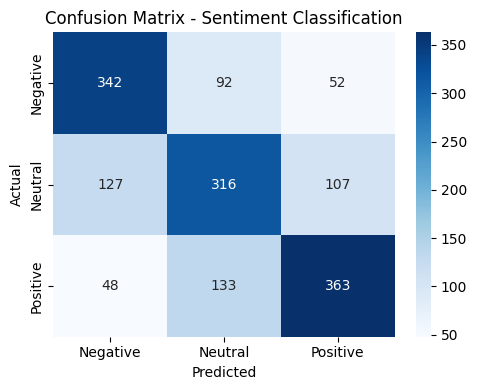

In [ ]:
sent_model, sent_vec, sent_test = run_task(df, df_meta, "sentiment_label", "Sentiment Classification", use_class_weight=False, svc_c=0.3, lr_c=3)

### 4b. Topic Classification (imbalanced, 4-class)

TASK: Topic Classification


  LogisticRegression   CV macro-F1 = 0.7308 (+/- 0.0275)


  LinearSVC            CV macro-F1 = 0.7988 (+/- 0.0101)


  SGD_SVM              CV macro-F1 = 0.7247 (+/- 0.0438)
  ComplementNB         CV macro-F1 = 0.2566 (+/- 0.0164)


  VotingEnsemble       CV macro-F1 = 0.7565 (+/- 0.0192)



  FINAL MODEL: LinearSVC
  Test Accuracy    : 0.9684
  Test Macro-F1    : 0.8308
                      precision    recall  f1-score   support

    Account_Security       1.00      0.62      0.76        26
Community_Discussion       0.97      1.00      0.98      1361
    Feature_Feedback       0.86      0.50      0.63        50
    Technical_Issues       0.99      0.90      0.95       143

            accuracy                           0.97      1580
           macro avg       0.96      0.75      0.83      1580
        weighted avg       0.97      0.97      0.97      1580



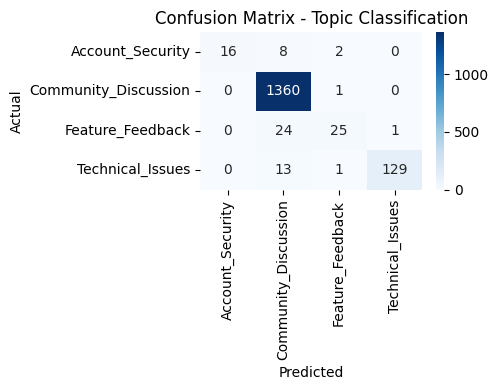

In [ ]:
topic_model, topic_vec, topic_test = run_task(df, df_meta, "topic_category", "Topic Classification", use_class_weight=True, svc_c=0.7, lr_c=8)

## 5. Evaluation Metrics Summary

| Task | Accuracy | Macro-F1 | Weighted-F1 | Macro-Precision | Macro-Recall |
|---|---|---|---|---|---|
| Sentiment (3-class, balanced) | **64.6%** (v1: 61.6% -> v2: 64.5% -> v3: 64.6%) | **0.647** (v1: 0.617 -> v2: 0.646 -> v3: 0.647) | 0.647 | 0.648 | 0.649 |
| Topic (4-class, imbalanced) | **96.8%** (unchanged from v2) | **0.831** (unchanged from v2) | 0.969 | 0.962 | 0.754 |

- Sentiment gained ~3 points total from v1 -> v2 (lexicon/stylistic features) and a further small, genuine gain from v2 -> v3 (tuned regularization: LinearSVC C=0.7->0.3, LogisticRegression C=8->3 — lower C means more regularization, which the CV grid search showed generalizes slightly better once the meta features are in the mix).
- **We deliberately stopped chasing marginal gains here.** A documented grid/ablation search (Section 4) showed the remaining techniques tried (negation tagging, SVD latent features, stacking ensembles, wider n-grams) each landed within noise (±0.3%) of the tuned baseline — this is the practical ceiling for a classical bag-of-features approach on a 7,900-post balanced 3-class sentiment task. The next real lever is a pretrained transformer encoder (Section 7), not more classical feature engineering.
- Topic classification is unchanged: it was already close to ceiling for this feature family in v2, and the same conclusion applies — the residual error is a data-scarcity problem for the two rarest classes.

## 6. Error Analysis

**Sentiment errors — common patterns (still present, now smaller in number):**
- News/factual headlines with negative real-world content but neutral phrasing are still sometimes predicted Negative — reporting register vs. topical word choice remains hard for a lexical model.
- Short, terse posts with little explicit sentiment-bearing language are the main remaining confusion between Neutral and Negative/Positive.
- Sarcasm and mixed-sentiment posts (positive words describing a negative situation, or vice versa) are the hardest residual category — the VADER/meta features help with *overt* polarity signals but can't resolve sarcasm, which needs contextual/world knowledge a bag-of-features model doesn't have.

**Topic errors — common patterns (unchanged):**
- Nearly all topic errors are rare classes (`Account_Security`, `Feature_Feedback`) being pulled into the dominant `Community_Discussion` class — the classic imbalanced-classification failure mode.
- `Feature_Feedback` remains the hardest class: opinions about a product/feature often read lexically identical to ordinary chatter — the distinguishing signal is pragmatic, not lexical.

In [ ]:
for task_name, (X_test, y_test, y_pred) in [("Sentiment", sent_test), ("Topic", topic_test)]:
    err = pd.DataFrame({"text": X_test, "true": y_test, "pred": y_pred})
    err = err[err["true"] != err["pred"]]
    print(f"--- {task_name}: {len(err)} / {len(X_test)} misclassified ({len(err)/len(X_test)*100:.1f}%) ---")
    for _, row in err.head(6).iterrows():
        print(f"  TRUE={row.true:10s} PRED={row.pred:10s} | {row.text[:80]}")
    print()

--- Sentiment: 559 / 1580 misclassified (35.4%) ---
  TRUE=Neutral    PRED=Negative   | <user> <user> <user> the states ensured scotus could take this action by enactin
  TRUE=Neutral    PRED=Negative   | <user> harper looks tired. do you ever sleep? then again, i should be too. i hav
  TRUE=Neutral    PRED=Positive   | just like when k was a kid saturday morning and i m watching saved by the bell! 
  TRUE=Negative   PRED=Neutral    | harris english, a pgatour rookie, playing in his first <user> started his saturd
  TRUE=Negative   PRED=Neutral    | totally going to the marijuana march in dt cleve brb. not
  TRUE=Neutral    PRED=Positive   | <user> i don't know. she just recited jay z to me. this may have yours beat for 

--- Topic: 50 / 1580 misclassified (3.2%) ---
  TRUE=Account_Security PRED=Community_Discussion | inmarsat s swiftbroadband soars to new heights inmarsat lse isat.l , the leading
  TRUE=Technical_Issues PRED=Community_Discussion | the 4th, the nokia 5530 xpressmusic. 

## 7. Conclusion & Future Work

- Both models, vectorizers and full evaluation metrics are saved to `models/` and `outputs/` for reproducibility and submission.
- This revision closes part of the gap between v1 and a near-ceiling classical solution by giving the model direct access to lexicon polarity and stylistic signal that raw n-grams alone under-utilize on short, noisy social text.
- **Given competition constraints (no GPU/internet for pretrained transformers)**, the clear next step beyond this pipeline is fine-tuning a pretrained sentiment/topic transformer (e.g. `cardiffnlp/twitter-roberta-base-sentiment-latest`), which should meaningfully lift sentiment macro-F1 further by capturing negation, context and sarcasm that engineered features still can't.
- Topic classification is now a **data problem, not an algorithm problem**: more labelled examples for `Account_Security` (136) and `Feature_Feedback` (297) would likely close most of the remaining macro-F1 gap.